# Scalability: what a search iteration costs, uniform against UCB

Two estimators for $\max_x \|\nabla \langle c, F(x)\rangle\|$ — uniform random search
(`StochasticApproximation`) and the adaptive UCB partition
(`StochasticApproximationUCBDynamic`) — measured on networks that grow along one axis at a
time. The question is the cost of scaling: how the price of one iteration and the wall time
of a whole search respond to a wider or a deeper network, and what the UCB bookkeeping adds
on top of the gradient it has to compute anyway.

The networks come from the planted generator (`benchmarks/planted.py`), used here only as a
means: it fixes $L(F) = c$ exactly, so a search can be stopped the moment it reaches the
true answer and the wall times compared are wall times *to the same result* rather than to
an arbitrary iteration budget. The planted width is held at $k = 5$ throughout, so the
statistical difficulty of the instance never changes and everything measured below is a
property of the networks and of the two methods.

| sweep | varies | held fixed |
|---|---|---|
| width | $d$, the input dimension and the distractor's width | `depth2` $= 8$ |
| depth | `depth2`, the distractor's depth | $d = 512$ |

Keeping the axes separate is deliberate: widening multiplies the parameters by four while
doubling the units, deepening doubles both, so a grid that grew them together could not say
which one an effect came from.

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'scripts_testing' else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts_testing'))

import planted_scalability as ps

# ---------------------------------------------------------------------------
# knobs
# ---------------------------------------------------------------------------
N_SEEDS = 25              # searches per (configuration, method)
K_PLANTED = 5             # planted width; sets the instance's difficulty, held fixed
RECOMPUTE = False         # True forces a re-run even if the cache is present

# The grids live in planted_scalability.py as WIDTH_GRID / DEPTH_GRID; override
# them here to plot a different range without touching the module.
WIDTH_GRID = ps.WIDTH_GRID          # [(d, 8), ...]      d = 128 ... 4096
DEPTH_GRID = ps.DEPTH_GRID          # [(512, depth2), ...]  depth2 = 4 ... 512
CACHE = ROOT / 'scripts_testing' / 'planted_out' / 'scalability_methods.json'

def show_path(p):
    """Path relative to the repo root when it is inside it, else as given."""
    p = Path(p)
    return p.relative_to(ROOT) if p.is_relative_to(ROOT) else p

# ---------------------------------------------------------------------------
if CACHE.exists() and not RECOMPUTE:
    data = json.loads(CACHE.read_text())
    print(f'loaded cached results from {show_path(CACHE)}')
else:
    print('computing both sweeps for both methods (~5 min at N_SEEDS = 25)')
    print('estimate first, so a wrong grid is caught before it runs:')
    ps.estimate_runtime(WIDTH_GRID, k=K_PLANTED, n_seeds=N_SEEDS)
    ps.estimate_runtime(DEPTH_GRID, k=K_PLANTED, n_seeds=N_SEEDS)
    print()
    data = {'width': ps.sweep_shapes(WIDTH_GRID, k=K_PLANTED, n_seeds=N_SEEDS),
            'depth': ps.sweep_shapes(DEPTH_GRID, k=K_PLANTED, n_seeds=N_SEEDS),
            'methods': list(ps.METHODS)}
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    CACHE.write_text(json.dumps(data, indent=1))
    print(f'wrote {show_path(CACHE)}')

width_recs, depth_recs = data['width'], data['depth']

# --- palette (validated: see the dataviz reference palette) -------------------
SURFACE, INK, INK_2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#8a8983'
BLUE, ORANGE = '#2a78d6', '#eb6834'
STYLE = {'uniform': (BLUE, 'o', 'uniform random search'),
         'ucb': (ORANGE, '^', 'UCB adaptive partition')}

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': '#d8d7d2', 'axes.linewidth': 0.8, 'axes.labelcolor': INK_2,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e8e7e2', 'grid.linewidth': 0.8,
    'font.size': 11, 'axes.titlesize': 12, 'legend.frameon': False,
    'figure.dpi': 120, 'lines.linewidth': 1.8, 'lines.markersize': 6,
})

# Each sweep is plotted against the axis it actually varies -- d for the width
# sweep, depth2 for the depth sweep -- because that is the quantity the reader
# controls. Parameter counts are in the table.
SWEEPS = [('width sweep', width_recs, 'd',
           'input dimension / distractor width  $d$'),
          ('depth sweep', depth_recs, 'depth2',
           'distractor depth  $\\mathtt{depth2}$')]

def axis(recs, key):
    return np.array([r[key] for r in recs])

def per_iter_ms(recs, method):
    return np.array([r['methods'][method]['per_iter_s'] for r in recs]) * 1e3

def med_seconds(recs, method):
    return np.array([np.median(r['methods'][method]['seconds']) for r in recs])

def med_iters(recs, method):
    return np.array([np.median(r['methods'][method]['evals']) for r in recs])

n_runs = sum(len(m['values']) for r in width_recs + depth_recs
             for m in r['methods'].values())
worst = max(abs(np.array(m['values']) / r['c'] - 1).max()
            for r in width_recs + depth_recs for m in r['methods'].values())
print(f'{n_runs} searches, both methods, k = {K_PLANTED}; '
      f'largest relative deviation from the true c: {worst:.1e}')

computing both sweeps for both methods (~5 min at N_SEEDS = 25)
estimate first, so a wrong grid is caught before it runs:
  d=   128 depth2=    8  uniform  per-iter=  0.327ms  ->       0.3s
  d=   128 depth2=    8      ucb  per-iter=  2.372ms  ->       1.9s
  d=   256 depth2=    8  uniform  per-iter=  0.311ms  ->       0.2s
  d=   256 depth2=    8      ucb  per-iter=  4.403ms  ->       3.5s
  d=   512 depth2=    8  uniform  per-iter=  0.552ms  ->       0.4s
  d=   512 depth2=    8      ucb  per-iter=  9.971ms  ->       8.0s
  d=  1024 depth2=    8  uniform  per-iter=  1.219ms  ->       1.0s
  d=  1024 depth2=    8      ucb  per-iter= 18.231ms  ->      14.6s
  d=  2048 depth2=    8  uniform  per-iter=  3.468ms  ->       2.8s
  d=  2048 depth2=    8      ucb  per-iter= 38.607ms  ->      30.9s
  d=  4096 depth2=    8  uniform  per-iter= 16.010ms  ->      12.8s
  d=  4096 depth2=    8      ucb  per-iter=113.193ms  ->      90.6s
  estimated total: 167s (2.8 min) for 25 seeds x 6 shapes x 2 

## Figure 1 — the cost of one iteration

Both methods compute the same gradient per iteration, so the gap between the two curves is
exactly what the UCB machinery costs: choosing a leaf by UCB score, drawing from that leaf's
pool of pre-generated points, and folding the value into the tree's statistics.

**The overhead is flat in depth and linear in the input dimension.** In the depth sweep it
sits at a constant ~8.4 ms whatever the network's depth, because none of that bookkeeping
touches the network. In the width sweep it grows in step with $d$ — each region node holds a
pool of $10\,005 \times d$ random points and regenerates it on exhaustion, and the
per-iteration updates are $O(d)$ as well. So the honest way to read the two panels: UCB pays
for the dimension of the input, uniform search pays for the size of the network.

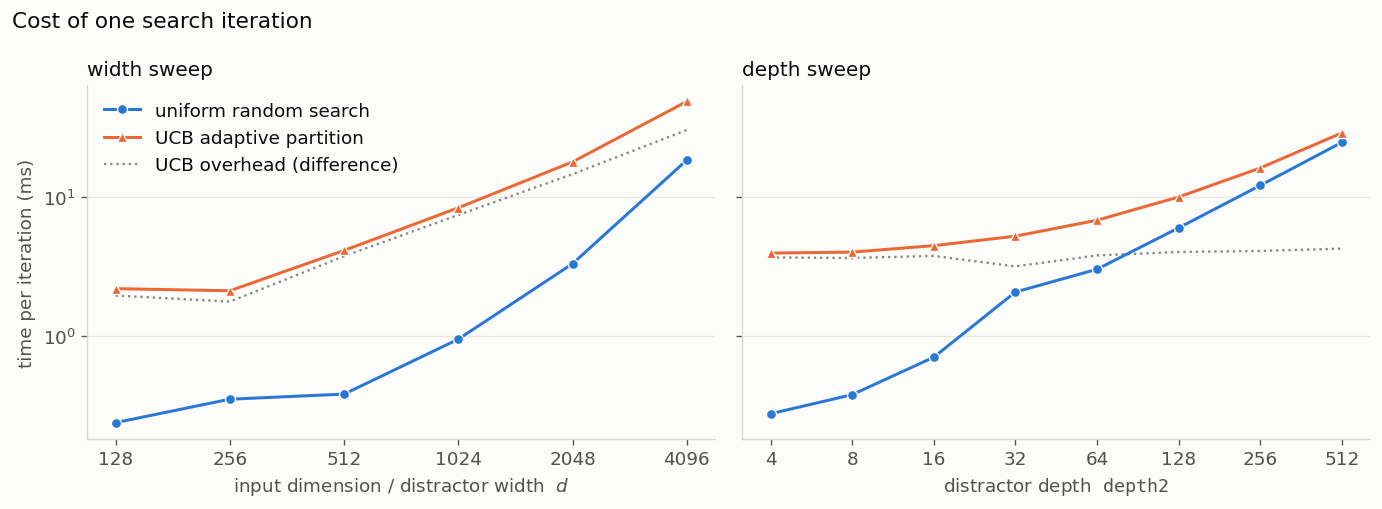

width sweep  UCB overhead    1.77 -   30.66 ms   ratio to uniform   2.6x -  10.9x
depth sweep  UCB overhead    3.17 -    4.26 ms   ratio to uniform   1.2x -  14.5x


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), sharey=True)

for ax, (name, recs, xkey, xlabel) in zip(axes, SWEEPS):
    x = axis(recs, xkey)
    for method, (colour, marker, label) in STYLE.items():
        ax.plot(x, per_iter_ms(recs, method), '-', marker=marker, color=colour,
                markeredgecolor=SURFACE, markeredgewidth=0.8, zorder=3, label=label)
    gap = per_iter_ms(recs, 'ucb') - per_iter_ms(recs, 'uniform')
    ax.plot(x, gap, ls=':', lw=1.4, color=MUTED, zorder=2, label='UCB overhead (difference)')
    ax.set_xscale('log', base=2); ax.set_yscale('log')
    ax.set_xticks(x); ax.set_xticklabels([str(v) for v in x])
    ax.minorticks_off()
    ax.set_xlabel(xlabel)
    ax.set_title(name, color=INK, loc='left')
    ax.grid(axis='y', zorder=0)

axes[0].set_ylabel('time per iteration (ms)')
axes[0].legend(loc='upper left')
fig.suptitle('Cost of one search iteration', color=INK, x=0.01, ha='left', size=13)
plt.tight_layout(); plt.show()

for name, recs, xkey, _ in SWEEPS:
    gap = per_iter_ms(recs, 'ucb') - per_iter_ms(recs, 'uniform')
    ratio = per_iter_ms(recs, 'ucb') / per_iter_ms(recs, 'uniform')
    print(f'{name:12s} UCB overhead {gap.min():7.2f} - {gap.max():7.2f} ms   '
          f'ratio to uniform {ratio.min():5.1f}x - {ratio.max():5.1f}x')

## Figure 2 — wall time of a whole search

Time until the estimate reaches the true $c$, which both methods do on every run, so these
are times to the same result. It is (iterations spent) × (cost of one), and the two factors
pull in opposite directions: on this instance the maximiser has measure $\rho = 2^{-k}$
everywhere in the domain, which is the case uniform sampling is already optimal for, so UCB
spends *more* iterations, not fewer, and pays more for each of them.

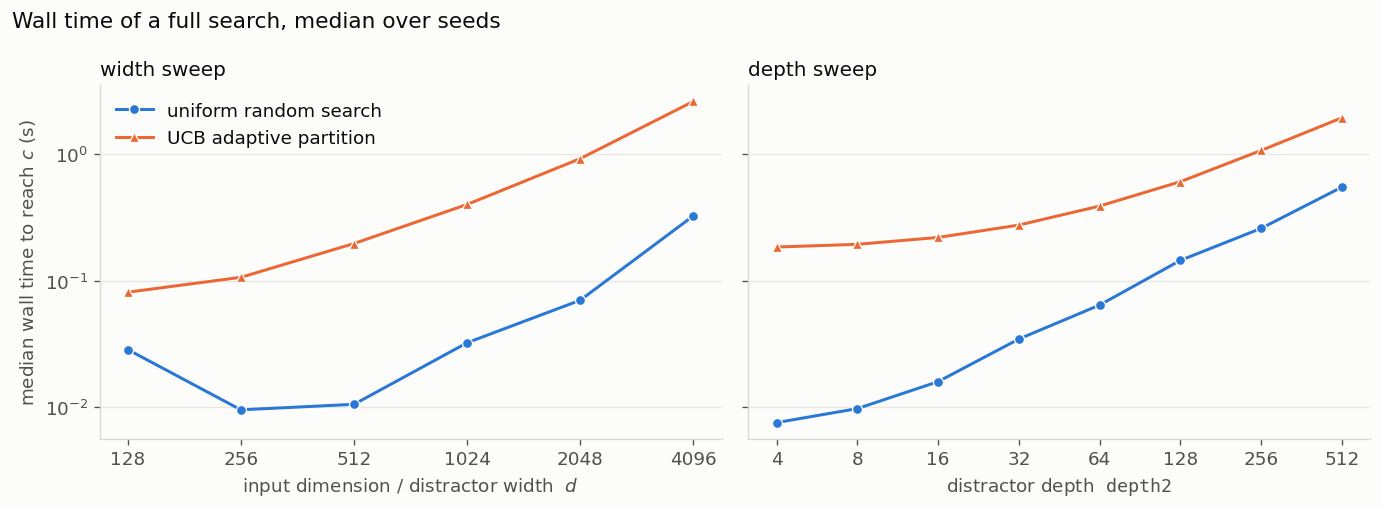

width sweep  UCB / uniform: wall time   2.8x -  18.6x, iterations   2.2x -   4.0x
depth sweep  UCB / uniform: wall time   3.5x -  24.4x, iterations   3.4x -   3.4x


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3), sharey=True)

for ax, (name, recs, xkey, xlabel) in zip(axes, SWEEPS):
    x = axis(recs, xkey)
    for method, (colour, marker, label) in STYLE.items():
        ax.plot(x, med_seconds(recs, method), '-', marker=marker, color=colour,
                markeredgecolor=SURFACE, markeredgewidth=0.8, zorder=3, label=label)
    ax.set_xscale('log', base=2); ax.set_yscale('log')
    ax.set_xticks(x); ax.set_xticklabels([str(v) for v in x])
    ax.minorticks_off()
    ax.set_xlabel(xlabel)
    ax.set_title(name, color=INK, loc='left')
    ax.grid(axis='y', zorder=0)

axes[0].set_ylabel('median wall time to reach $c$ (s)')
axes[0].legend(loc='upper left')
fig.suptitle('Wall time of a full search, median over seeds', color=INK,
             x=0.01, ha='left', size=13)
plt.tight_layout(); plt.show()

for name, recs, xkey, _ in SWEEPS:
    ratio = med_seconds(recs, 'ucb') / med_seconds(recs, 'uniform')
    it = med_iters(recs, 'ucb') / med_iters(recs, 'uniform')
    print(f'{name:12s} UCB / uniform: wall time {ratio.min():5.1f}x - {ratio.max():5.1f}x, '
          f'iterations {it.min():5.1f}x - {it.max():5.1f}x')

## Every number

`value/c` is the recovered constant over the true one, min–max across seeds — the check that
both methods really did reach the same answer before the clock was stopped. `iters` and
`wall` are medians over `N_SEEDS` searches.

In [4]:
def table(name, recs):
    print(f'{name.upper()}   (k = {K_PLANTED}, {N_SEEDS} seeds per cell)')
    hdr = (f"{'d':>6} {'depth2':>7} {'units':>9} {'params':>9} {'method':>9} "
           f"{'value/c':>20} {'iters':>7} {'per iter':>10} {'wall':>9}")
    print(hdr); print('-' * len(hdr))
    for r in recs:
        for i, (method, m) in enumerate(r['methods'].items()):
            v = np.array(m['values']) / r['c']
            head = (f"{r['d']:>6} {r['depth2']:>7} {r['n_neurons']:>9} "
                    f"{r['n_params'] / 1e6:>8.1f}M" if i == 0 else ' ' * 34)
            print(f"{head} {method:>9} {v.min():.6f}–{v.max():.6f} "
                  f"{int(np.median(m['evals'])):>7} "
                  f"{m['per_iter_s'] * 1e3:>9.3f}ms "
                  f"{np.median(m['seconds']):>8.3f}s")
    print()

table('width sweep', width_recs)
table('depth sweep', depth_recs)

hits = [h for r in width_recs + depth_recs for m in r['methods'].values() for h in m['hits']]
print(f'{len(hits)} searches, hit rate {np.mean(hits):.0%}')

WIDTH SWEEP   (k = 5, 25 seeds per cell)
     d  depth2     units    params    method              value/c   iters   per iter      wall
----------------------------------------------------------------------------------------------
   128       8       877      0.1M   uniform 1.000000–1.000000      32     0.237ms    0.029s
                                         ucb 1.000000–1.000000      70     2.193ms    0.081s
   256       8      1773      0.5M   uniform 1.000000–1.000000      19     0.349ms    0.010s
                                         ucb 1.000000–1.000000      72     2.118ms    0.107s
   512       8      3565      2.1M   uniform 1.000000–1.000000      21     0.380ms    0.011s
                                         ucb 1.000000–1.000000      71     4.140ms    0.197s
  1024       8      7149      8.3M   uniform 1.000000–1.000000      29     0.947ms    0.032s
                                         ucb 1.000000–1.000000      71     8.415ms    0.401s
  2048       8     14317 